In [208]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error , mean_squared_error , mean_absolute_error , r2_score

In [209]:
df = pd.read_csv('WineQT.csv')

In [210]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [211]:
df = df.drop(columns=['Id'])

In [212]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [213]:
df.shape

(1143, 12)

In [214]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1141.000000,1141.000000,1142.000000,1143.000000,1142.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086936,15.624452,45.936515,0.996730,3.310806,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047308,10.255500,32.788190,0.001925,0.156573,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.202500,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [215]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               2
free sulfur dioxide     2
total sulfur dioxide    1
density                 0
pH                      1
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [216]:
df['chlorides'] = df['chlorides'].fillna(df['chlorides'].mean())

In [217]:
df['free sulfur dioxide'] = df['free sulfur dioxide'].fillna(df['free sulfur dioxide'].mean())

In [218]:
df['total sulfur dioxide'] = df['total sulfur dioxide'].fillna(df['total sulfur dioxide'].mean())

In [219]:
df['pH'] = df['pH'].fillna(df['pH'].mean())

In [220]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [221]:
df['quality'].value_counts()

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

In [222]:
df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.108144,-0.162324,-0.108716,0.681501,-0.684629,0.174592,-0.075055,0.121970
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056208,-0.002132,0.076798,0.016512,0.220089,-0.276079,-0.203909,-0.407394
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245557,-0.055988,0.038072,0.375243,-0.545139,0.331232,0.106250,0.240821
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070914,0.165650,0.190872,0.380147,-0.116948,0.017475,0.058421,0.022002
chlorides,0.108144,0.056208,0.245557,0.070914,1.000000,0.015582,0.048189,0.209108,-0.277820,0.374932,-0.229794,-0.124144
free sulfur dioxide,-0.162324,-0.002132,-0.055988,0.165650,0.015582,1.000000,0.660136,-0.053382,0.071193,0.035711,-0.045980,-0.062978
total sulfur dioxide,-0.108716,0.076798,0.038072,0.190872,0.048189,0.660136,1.000000,0.051388,-0.059275,0.026949,-0.188669,-0.183102
density,0.681501,0.016512,0.375243,0.380147,0.209108,-0.053382,0.051388,1.000000,-0.352280,0.143139,-0.494727,-0.175208
pH,-0.684629,0.220089,-0.545139,-0.116948,-0.277820,0.071193,-0.059275,-0.352280,1.000000,-0.185314,0.222636,-0.053076
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374932,0.035711,0.026949,0.143139,-0.185314,1.000000,0.094421,0.257710


In [223]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

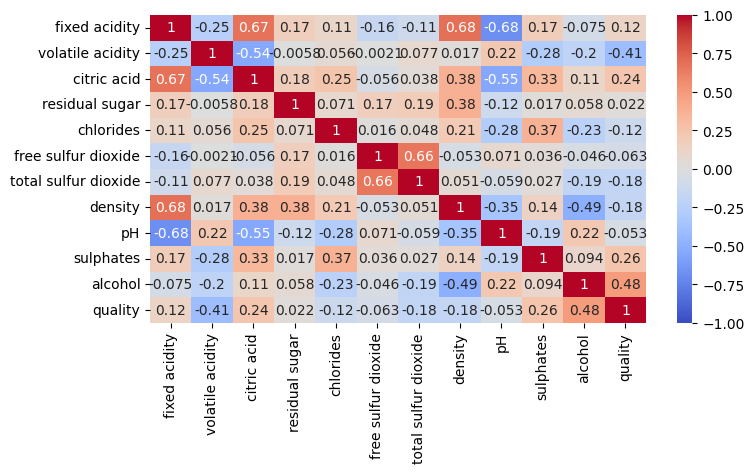

In [224]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr() , cmap='coolwarm' , annot=True ,vmin=-1,vmax=1)

In [225]:
##model training
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import train_test_split

In [226]:
X = df[['alcohol']]

In [227]:
y = df[['quality']]

In [228]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.33, random_state=42)

In [229]:
model = LinearRegression()

In [230]:
alc_model = model.fit(X_train , y_train)

In [231]:
y_pred = alc_model.predict(X_test)

In [232]:
# from sklearn.metrics import root_mean_squared_error , mean_squared_error , mean_absolute_error , r2_score

In [233]:
mse = mean_squared_error(y_test , y_pred)
rmse = root_mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

In [234]:
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 0.4490642375622527
RMSE: 0.6701225541363705
MAE : 0.5398759736952057
R²  : 0.2639706510984109


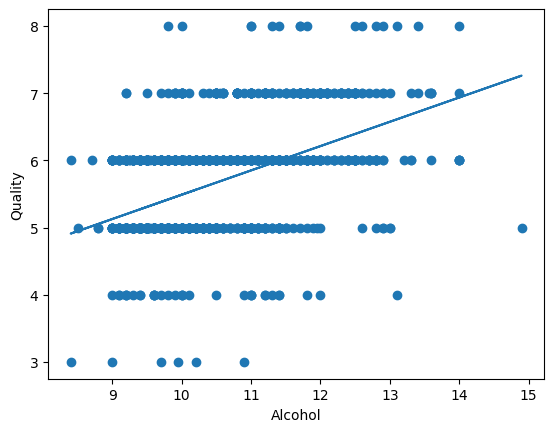

In [235]:

plt.scatter(df['alcohol'], df['quality'])
plt.plot(df['alcohol'], alc_model.predict(df[['alcohol']]))
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.show()

In [236]:
#model with selective feature abs(corr) > .20

In [237]:
selective_features = df[['alcohol','volatile acidity','sulphates','citric acid']]


In [238]:
X_train , X_test , y_train , y_test = train_test_split(selective_features , y , test_size=.33 , random_state=42)

In [239]:
sel_model = model.fit(X_train , y_train)  

In [240]:
y_pred = sel_model.predict(X_test)

In [241]:
mse = mean_squared_error(y_test , y_pred)
rmse = root_mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

In [242]:
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 0.39212507369949906
RMSE: 0.6261989090532648
MAE : 0.4897520785294665
R²  : 0.357295597062503


In [243]:
#all features

In [244]:
all_feat = df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']]

In [245]:
X_train , X_test , y_train , y_test = train_test_split(all_feat , y , test_size=.33 , random_state=42)

In [246]:
all_model = model.fit(X_train ,y_train )

In [247]:
y_pred = all_model.predict(X_test)

In [248]:
mse = mean_squared_error(y_test , y_pred)
rmse = root_mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

In [249]:
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 0.3859514449010623
RMSE: 0.6212499053529604
MAE : 0.4808331728298922
R²  : 0.36741435425755486


In [250]:
def print_quality(
    fixed_acidity,
    volatile_acidity,
    citric_acid,
    residual_sugar,
    chlorides,
    free_sulfur_dioxide,
    total_sulfur_dioxide,
    density,
    pH,
    sulphates,
    alcohol
):
    prediction = all_model.predict([[
        fixed_acidity,
        volatile_acidity,
        citric_acid,
        residual_sugar,
        chlorides,
        free_sulfur_dioxide,
        total_sulfur_dioxide,
        density,
        pH,
        sulphates,
        alcohol
    ]])

    print("Predicted Quality:", prediction)

In [251]:
print_quality(
    7.4,       # fixed acidity
    0.7,       # volatile acidity
    0.0,       # citric acid
    1.9,       # residual sugar
    0.076,     # chlorides
    11,        # free sulfur dioxide
    34,        # total sulfur dioxide
    0.9978,    # density
    3.51,      # pH
    0.56,      # sulphates
    9.4        # alcohol
)

Predicted Quality: [[5.06075544]]


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
